# 02 · Experten + Gating (Track B: SQI-gated Mixture of Experts)

**Bachelorarbeit: AF-Detektion in kontaktlosen Signalen · Nik Büttner · RWTH Aachen**

Dieses Notebook setzt die von Blaß gewünschte Architektur zusammen und wertet sie aus:

1. **Drei Experten** (cECG / PPG / BCG) liefern je eine fensterweise AF-Wahrscheinlichkeit.
2. Das **Gating-Netz** sagt aus den SQIs den Zuverlässigkeits-Fehler jeder Modalität
   vorher (Ziel aus dem GT-EKG, Bachelet-Stil) und macht daraus Gewichte.
3. **Gewichtete Fusion** → fensterweise AF-Entscheidung.

Alles läuft **leckagefrei**: patientenweise LOPO-CV (kein Patient in Train *und* Test),
Out-of-Fold-Experten-Outputs fürs Gate, und das GT-EKG fließt **nur** ins Trainings-Ziel
des Gates — nie in den Test-Pfad.

> **Voraussetzung:** `01_features_sqi.ipynb` wurde gelaufen (Feature-Tabelle liegt im
> `data/`-Ordner). Für die Reliability-Tabelle wird `neurokit2` benötigt (GT-R-Zacken);
> ohne neurokit2 greift ein einfacher Fallback-Detektor.


& c:\Users\sshuser\Documents\BA\.venv\Scripts\Activate.ps1

Start-Process -FilePath "c:\Users\sshuser\Documents\BA\.venv\Scripts\jupyter.exe" `
  -ArgumentList "notebook --no-browser --port=8888 --NotebookApp.token=mytoken" `
  -WindowStyle Hidden‚

## 1 · Imports, Pfade, Feature-Tabelle laden

In [1]:
import os, sys, glob
import numpy as np, pandas as pd

NB_DIR  = os.path.abspath('')
SRC_DIR = os.path.abspath(os.path.join(NB_DIR, '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import extract as E
import experts as X
import reliability as R
import gating as G
import fusion_cv as CV
import models as M

DATA_ROOT = '../data/patients/'
DATA_DIR  = '../results/'

# Feature-Tabelle aus Notebook 01 (jüngste features_sqi_*.csv nehmen)
feat_files = sorted(glob.glob(os.path.join(DATA_DIR, 'features_sqi_*.csv')), key=os.path.getmtime)
assert feat_files, 'Keine Feature-Tabelle gefunden — erst 01_features_sqi.ipynb laufen lassen.'
df = pd.read_csv(feat_files[-1])
df, y, groups = E.split_Xygroups(df)
print('Features:', df.shape, '·', feat_files[-1])

Features: (4724, 170) · ../results\features_sqi_cecg_cwt_d2721c.csv


## 2 · Reliability-Tabelle (GT-EKG-basiertes Gate-Ziel)

Berechnet je Fenster, wie treu jede Modalität den wahren Rhythmus abbildet. Das ist
das **Trainings-Ziel** des Gates (nur hier wird das GT-EKG genutzt). Wird gecached.

`target_metric='cosen_err'` ist das AF-passende Default-Ziel (Fehler im stärksten
AF-Diskriminator). Die Tabelle enthält zusätzlich `hr_err` (Bachelet-Vergleich) und
`drr_sd_err`, sodass das Ziel später ohne Neuberechnung umgeschaltet werden kann.

In [2]:
REL_CACHE = os.path.join(DATA_DIR, 'reliability_cosen.csv')

if os.path.exists(REL_CACHE):
    rel = pd.read_csv(REL_CACHE)
    print('Reliability-Cache geladen:', rel.shape)
else:
    rel = R.build_reliability_table(DATA_ROOT, target_metric='cosen_err', n_jobs=8)
    rel.to_csv(REL_CACHE, index=False)
    print('Reliability gespeichert:', REL_CACHE)

# Abdeckung: wie oft liefert jede Modalität überhaupt einen Rhythmus?
for m in ['cecg', 'ppg', 'bcg']:
    print(f'  {m}: gültig in {rel[f"rel_{m}_valid"].mean()*100:.0f}% der Fenster')
rel.head(3)

Reliability-Cache geladen: (4701, 17)
  cecg: gültig in 100% der Fenster
  ppg: gültig in 93% der Fenster
  bcg: gültig in 47% der Fenster


,rel_cecg_valid,rel_cecg_hr_err,rel_cecg_cosen_err,rel_cecg_drr_sd_err,rel_cecg_target,rel_ppg_valid,rel_ppg_hr_err,rel_ppg_cosen_err,rel_ppg_drr_sd_err,rel_ppg_target,rel_bcg_valid,rel_bcg_hr_err,rel_bcg_cosen_err,rel_bcg_drr_sd_err,rel_bcg_target,patient,win_idx
0,True,0.174376,1.862751,69.059301,1.862751,True,35.604124,0.402029,7.049572,0.402029,False,NaN,NaN,NaN,NaN,PAT001,0
1,True,0.809775,0.191751,12.053732,0.191751,True,48.535165,0.389507,94.636297,0.389507,True,5.223822,1.534347,165.864732,1.534347,PAT001,1
2,True,0.226654,0.328805,7.619548,0.328805,True,39.244175,0.220716,141.925745,0.220716,True,1.105909,1.411498,172.957288,1.411498,PAT001,2


## 3 · Experten solo (Sanity + Modalitäts-Story)

Out-of-Fold-AUC je Experte. Erwartung aus deinen bisherigen Ergebnissen: PPG trägt
das Signal, cECG mittel, BCG schwach. Das ist genau die Asymmetrie, die das Gate
ausnutzen soll.

In [3]:
from sklearn.metrics import roc_auc_score
oof = X.oof_expert_probs(df, y, groups, n_splits=5)
print('Out-of-Fold-AUC je Experte:')
for m in G.ORDER:
    print(f'  {m:5s}: {roc_auc_score(y, oof[f"p_{m}"]):.3f}')

Out-of-Fold-AUC je Experte:
  cecg : 0.787
  ppg  : 0.884
  bcg  : 0.680


In [4]:
# Experten-Schicht EINMAL je Fold berechnen (parallel) und über alle Gate-Varianten nutzen.
# Unabhängig von der Reliability-Tabelle -> der Stage-0-Rebuild invalidiert diesen Cache NICHT.
fold_cache = CV.precompute_folds(df, y, groups, inner_splits=5, random_state=42,
                                 n_jobs=-1, cache_dir=DATA_DIR)

Fold-Cache gefunden -> lade ../results/fold_expert_cache_3129042d39e73e97.joblib


## 4 · Hauptergebnis: gelerntes Gate vs. naive Fusion

Die zentrale Frage der Arbeit: bringt das datengetriebene, SQI-gesteuerte Gating
etwas gegenüber gleichgewichteter Fusion? `equal` = Baseline, `ridge/gb/mlp` =
gelernte Gates. Auswertung fensterweise in patientenweiser LOPO-CV.

In [5]:
tab = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','ridge','gb','mlp'),
                       inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
cols = ['gate', 'AUC', 'Sensitivität', 'Spezifität', 'Accuracy', 'threshold']
tab[cols].round(3)

,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.930,0.900,0.802,0.849,0.483
1,ridge,0.938,0.913,0.784,0.845,0.472
2,gb,0.937,0.928,0.758,0.839,0.458
3,mlp,0.932,0.920,0.756,0.834,0.464


## 5 · Sensitivität des Gate-Ziels (CoSEn vs. HR vs. dRR-SD)

Welche Definition von „Zuverlässigkeit" trainiert das beste Gate? Dieselbe
Reliability-Tabelle, nur anderes Ziel — kein Neuberechnen nötig. `hr_err` entspricht
Bachelets HR-Fehler, `cosen_err`/`drr_sd_err` sind die AF-Rhythmus-Varianten.

In [6]:
rows = []
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    m, t = CV.evaluate_moe(df, rel, y, groups, gate_kind='gb',
                           target_metric=tm, inner_splits=5, fold_cache=fold_cache)
    rows.append({'target': tm, **{k: m[k] for k in ['AUC','Sensitivität','Spezifität','Accuracy']}})
pd.DataFrame(rows).round(3)

,target,AUC,Sensitivität,Spezifität,Accuracy
0,cosen_err,0.937,0.928,0.758,0.839
1,drr_sd_err,0.936,0.922,0.766,0.841
2,hr_err,0.910,0.895,0.762,0.826


## 6 · Konfidenzintervalle der besten Konfiguration

Patienten-Cluster-Bootstrap (hält alle Fenster eines Patienten zusammen) — konsistent
zur Auswertung deiner bisherigen `window_nested`-Ergebnisse.

In [7]:
BEST_GATE   = 'gb'          # nach Tabelle in Abschnitt 4 wählen
BEST_TARGET = 'cosen_err'   # nach Tabelle in Abschnitt 5 wählen

m, t, yt, yp, yd, yg = CV.evaluate_moe(
    df, rel, y, groups, gate_kind=BEST_GATE, target_metric=BEST_TARGET,
    inner_splits=5, min_spec=0.80, return_arrays=True, fold_cache=fold_cache)

ci = M.bootstrap_ci(yt, yp, t, n_boot=2000, groups=yg)
print(f'Beste Konfiguration: gate={BEST_GATE}, target={BEST_TARGET}, threshold={t:.3f}\n')
for k in ['AUC', 'Sensitivität', 'Spezifität', 'Accuracy']:
    lo, hi = ci[k]
    print(f'  {k:12s}: {m[k]:.3f}  [{lo:.3f}, {hi:.3f}]')

Beste Konfiguration: gate=gb, target=cosen_err, threshold=0.458

  AUC         : 0.937  [0.884, 0.976]
  Sensitivität: 0.928  [0.892, 0.976]
  Spezifität  : 0.758  [0.648, 0.879]
  Accuracy    : 0.839  [0.778, 0.913]


In [8]:
# Stage 0.5 — sagt der SQI das Zuverlässigkeits-Ziel überhaupt voraus?
# Wurzel-Ursache für flache Gewichte: ohne SQI->Fehler-Zusammenhang kann KEINE
# Gewichtungskurve (Softmax oder Bachelet) die Fusion fensterweise steuern.
pv = CV.gate_predictive_validity(df, rel, y, groups,
                                 gate_kind=BEST_GATE, target_metric=BEST_TARGET)
print('Gate-Prädiktionsgüte (nur Fenster mit gültigem GT-Ziel):')
pv.round(3)

Gate-Prädiktionsgüte (nur Fenster mit gültigem GT-Ziel):


,r,rho,R2_vs_train_mean,n_valid
modality,,,,
cecg,0.069,0.042,-0.061,4695
ppg,0.355,0.253,0.120,4382
bcg,0.035,0.042,-0.012,2203


## 7 · Adaptivität des Gates — Kernprüfung

Track B behauptet: die **fensterweise** SQI-Information steuert die Fusion. Diese
Prüfung trennt das in zwei Beiträge — eine feste, gelernte Modalitätsgewichtung
vs. die zusätzliche Pro-Fenster-Anpassung — und misst beide unabhängig:

- **`compare_adaptivity`**: `equal` (1/3 fix) → `*-fix` (gelerntes, eingefrorenes
  Mittelgewicht) → `*-win` (volles Pro-Fenster-Gate). Δ(fix→win) = was die
  fensterweise Steuerung *für die Metrik* bringt.
- **`gate_weight_report`**: misst, wie stark sich die Gewichte *innerhalb eines
  Patienten* bewegen (`std_within_patient`). ≈ 0 ⇒ das Gate reagiert nicht auf die
  fensterweise Signalqualität.3 

In [9]:
adt = CV.compare_adaptivity(df, rel, y, groups,
                            base_gate=BEST_GATE, target_metric=BEST_TARGET,
                            inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
acols = ['variant', 'AUC', 'Sensitivität', 'Spezifität', 'Accuracy', 'threshold']
adt[acols].round(3)

,variant,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.930,0.900,0.802,0.849,0.483
1,gb-fix,0.941,0.918,0.799,0.856,0.468
2,gb-win,0.937,0.928,0.758,0.839,0.458


In [10]:
rep, W = CV.gate_weight_report(df, rel, y, groups,
                               gate_kind=BEST_GATE, target_metric=BEST_TARGET,
                               inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print('Wie stark bewegt das Gate seine Gewichte? (std_within_patient ist der Kernwert)')
rep.round(3)

Wie stark bewegt das Gate seine Gewichte? (std_within_patient ist der Kernwert)


,mean_weight,std_overall,std_within_patient,cv_within_patient
cecg,0.414,0.093,0.066,0.160
ppg,0.433,0.108,0.070,0.161
bcg,0.152,0.078,0.052,0.342


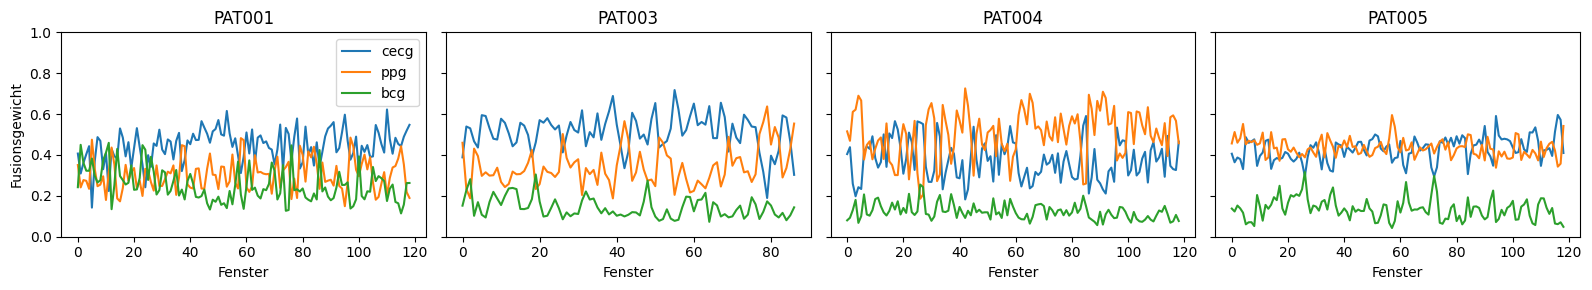

In [11]:
import matplotlib.pyplot as plt
ex = list(pd.unique(W['patient']))[:4]            # vier Beispiel-Patienten
fig, axes = plt.subplots(1, len(ex), figsize=(4 * len(ex), 3), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), ex):
    sub = W[W['patient'] == pid]
    for m in G.ORDER:
        ax.plot(range(len(sub)), sub[f'w_{m}'].values, label=m)
    ax.set_title(pid); ax.set_xlabel('Fenster'); ax.set_ylim(0, 1)
np.atleast_1d(axes)[0].set_ylabel('Fusionsgewicht'); np.atleast_1d(axes)[0].legend()
plt.tight_layout(); plt.show()

In [12]:
XGB_CLF = {'cecg': 'XGB', 'ppg': 'XGB', 'bcg': 'XGB'}

# Cache ist nach clf verschlüsselt -> für XGB neu bauen (eigene Datei, LR-Cache bleibt)
fold_cache_xgb = CV.precompute_folds(df, y, groups, clf_per_modality=XGB_CLF,
                                     inner_splits=5, random_state=42,
                                     n_jobs=-1, cache_dir=DATA_DIR)

# Pro-Experte OOF-AUC mit XGB  (vs. LR: cECG 0.787 / PPG 0.884 / BCG 0.680)
from sklearn.metrics import roc_auc_score
oof_xgb = X.oof_expert_probs(df, y, groups, clf_per_modality=XGB_CLF, n_splits=5)
for m in G.ORDER:
    print(f'  {m:5s}: OOF-AUC = {roc_auc_score(y, oof_xgb[f"p_{m}"]):.3f}')

# Fusions-Vergleich mit XGB-Experten (inkl. xgb-Gate aus Schritt 1)
tab_xgb = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','gb','xgb'),
                           clf_per_modality=XGB_CLF, inner_splits=5, min_spec=0.80,
                           fold_cache=fold_cache_xgb)
tab_xgb[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

Berechne Experten-Schicht für 40 Folds (sig=a6112aa40e8dbf5e, n_jobs=-1) ...
  fertig in 45.8s · 40 Folds
  gespeichert: ../results/fold_expert_cache_a6112aa40e8dbf5e.joblib
  cecg : OOF-AUC = 0.850
  ppg  : OOF-AUC = 0.834
  bcg  : OOF-AUC = 0.721


,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.909,0.842,0.802,0.821,0.465
1,gb,0.909,0.865,0.772,0.817,0.448
2,xgb,0.911,0.862,0.779,0.818,0.449


In [14]:
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    pv = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='xgb', target_metric=tm)
    print(f'\nZiel = {tm}\n{pv.round(3).to_string()}')


Ziel = cosen_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.075  0.074            -0.027     4695
ppg       0.340  0.241             0.124     4382
bcg       0.025  0.029            -0.011     2203

Ziel = drr_sd_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.503  0.519             0.272     4695
ppg       0.324  0.362             0.107     4382
bcg       0.032  0.026            -0.023     2203

Ziel = hr_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.363  0.350             0.143     4695
ppg       0.454  0.517             0.218     4382
bcg       0.366  0.379             0.131     2203


In [15]:
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    pv = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='gb', target_metric=tm)
    print(f'\nZiel = {tm}\n{pv.round(3).to_string()}')


Ziel = cosen_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.069  0.042            -0.061     4695
ppg       0.355  0.253             0.120     4382
bcg       0.035  0.042            -0.012     2203

Ziel = drr_sd_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.454  0.501             0.213     4695
ppg       0.300  0.361             0.082     4382
bcg       0.003 -0.006            -0.067     2203

Ziel = hr_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg      0.342  0.352             0.110     4695
ppg       0.449  0.472             0.215     4382
bcg       0.321  0.313             0.100     2203


## Nächste Schritte

- **Klassifikator je Experte** variieren: `clf_per_modality={'cecg':'RF','ppg':'LR','bcg':'GB'}`
  an `compare_gates`/`evaluate_moe` übergeben.
- **Gate als echtes KNN** (PyTorch + Optuna) wie bei Bachelet — der sklearn-`mlp`
  ist der Einstieg; die Schnittstelle (`gating.make_gate`) bleibt gleich.
- **Erklärbarkeit**: zeigen, wovon das Gate seine Gewichte ableitet (welche SQIs
  treiben das vorhergesagte Vertrauen?) — Integrated Gradients / Permutation Importance.

**Mit Blaß bestätigen:**
1. Gate-Ziel = RR-Irregularitäts-Treue (CoSEn), nicht reiner HR-Fehler — passt das zu AF?
2. Kanal-Aggregation PPG/BCG = bester Kanal (kleinster Fehler) — oder Mittelwert?
3. Experten eingefroren, Gate darüber trainiert (B/Stacking) — wie besprochen.
